4.5 GBM (Gradient Boosting Machine)

In [1]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the dataset and split it
dataset = load_breast_cancer()
X_features = dataset.data
y_label = dataset.target
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label,
                                                  test_size=0.2, random_state=156)

# GBM 수행 시간 측정을 위함. 시작 시간 설정.
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print("GBM 수행 시간: {0:.1f} 초 ".format(time.time() - start_time))

GBM 정확도: 0.9561
GBM 수행 시간: 1.4 초 


4.6 XGBoost - 파이썬 래퍼 XGBoost 실습: 위스콘신 유방암 예측

In [2]:
pip install xgboost==1.5.0

  Using cached xgboost-1.5.0-py3-none-manylinux2014_x86_64.whl.metadata (1.7 kB)
Using cached xgboost-1.5.0-py3-none-manylinux2014_x86_64.whl (173.5 MB)
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


In [3]:
!pip install --upgrade xgboost

  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
  Attempting uninstall: xgboost
    Found existing installation: xgboost 1.5.0
    Uninstalling xgboost-1.5.0:
      Successfully uninstalled xgboost-1.5.0


['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64
(455, 30) (114, 30)
[0]	train-logloss:0.58417	eval-logloss:0.56499
[1]	train-logloss:0.51864	eval-logloss:0.50615
[2]	train-logloss:0.46435	eval-logloss:0.45818
[3]	train-logloss:0.41691	eval-logloss:0.41774
[4]	train-logloss:0.37564	eval-logloss:0.38060
[5]	train-logloss:0.34054	eval-logloss:0.35098
[6]	train-logloss:0.31009	eval-logloss:0.32552
[7]	train-logloss:0.28265	eval-logloss:0.30095
[8]	train-logloss:0.25909	eval-logloss:0.28167
[9]	train-logloss:0.23807	eval-logloss:0.26239
[10]	train-logloss:0.21937	eval-logloss:0.24797
[11]	train-logloss:0.20238	eval-logloss:0.23210
[12]	train-logloss:0.18748	eval-logloss:0.22060
[13]	train-logloss:0.17376	eval-logloss:0.20778
[14]	train-logloss:0.16181	eval-logloss:0.19775
[15]	train-logloss:0.15094	eval-logloss:0.18975
[16]	train-logloss:0.14116	eval-logloss:0.18064
[17]	train-logloss:0.13156	eval-logloss:0.17250
[18]	train-logloss:0.12323	eval-logloss:0.16517
[19]

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

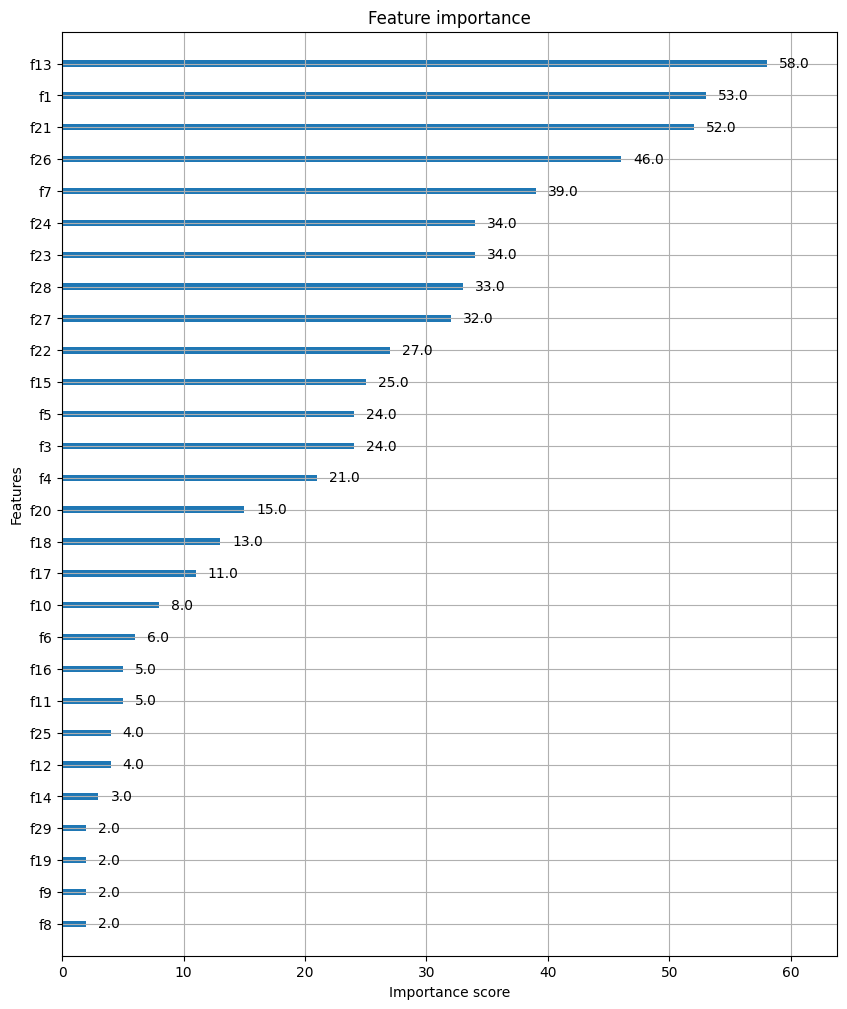

In [4]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
X_features = dataset.data
y_label = dataset.target

cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)
cancer_df['target'] = y_label
cancer_df.head(3)

print(dataset.target_names)
print(cancer_df['target'].value_counts())

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label,
                                                  test_size=0.2, random_state=156 )
print(X_train.shape , X_test.shape)

dtrain = xgb.DMatrix(data=X_train, label=y_train)
dtest = xgb.DMatrix(data=X_test, label=y_test)

params = { 'max_depth':3,
           'eta': 0.1,
           'objective':'binary:logistic',
           'eval_metric':'logloss'
         }
num_rounds = 400

# train 데이터 세트는 'train' , evaluation(test) 데이터 세트는 'eval' 로 명기합니다.
wlist = [ (dtrain,'train'),(dtest,'eval') ]
# 하이퍼 파라미터와 train 데이터 세트 전달. 루프 횟수는 400회. 학습 데이터 세트는 dtrain , 성능 평가 데이터 세트는 dtest로 명기
xgb_model = xgb.train(params = params , dtrain=dtrain , num_boost_round=num_rounds , \
                      early_stopping_rounds=100, evals=wlist )

pred_probs = xgb_model.predict(dtest)
print('predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10], 3))

# 예측 확률이 0.5 보다 크면 1 , 그렇지 않으면 0 으로 예측값 결정하여 리스트 객체인 preds에 저장
preds = [ 1 if x > 0.5 else 0 for x in pred_probs ]
print('예측 결과 10개만 표시:',preds[:10])

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

get_clf_eval(y_test , preds, pred_probs)

import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)

4.7 LightGBM

In [5]:
pip install lightgbm==3.3.2

[1]	training's binary_logloss: 0.625671	valid_1's binary_logloss: 0.628248
[2]	training's binary_logloss: 0.588173	valid_1's binary_logloss: 0.601106
[3]	training's binary_logloss: 0.554518	valid_1's binary_logloss: 0.577587
[4]	training's binary_logloss: 0.523972	valid_1's binary_logloss: 0.556324
[5]	training's binary_logloss: 0.49615	valid_1's binary_logloss: 0.537407
[6]	training's binary_logloss: 0.470108	valid_1's binary_logloss: 0.519401
[7]	training's binary_logloss: 0.446647	valid_1's binary_logloss: 0.502637
[8]	training's binary_logloss: 0.425055	valid_1's binary_logloss: 0.488311
[9]	training's binary_logloss: 0.405125	valid_1's binary_logloss: 0.474664
[10]	training's binary_logloss: 0.386526	valid_1's binary_logloss: 0.461267
[11]	training's binary_logloss: 0.367027	valid_1's binary_logloss: 0.444274
[12]	training's binary_logloss: 0.350713	valid_1's binary_logloss: 0.432755
[13]	training's binary_logloss: 0.334601	valid_1's binary_logloss: 0.421371
[14]	training's binary

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

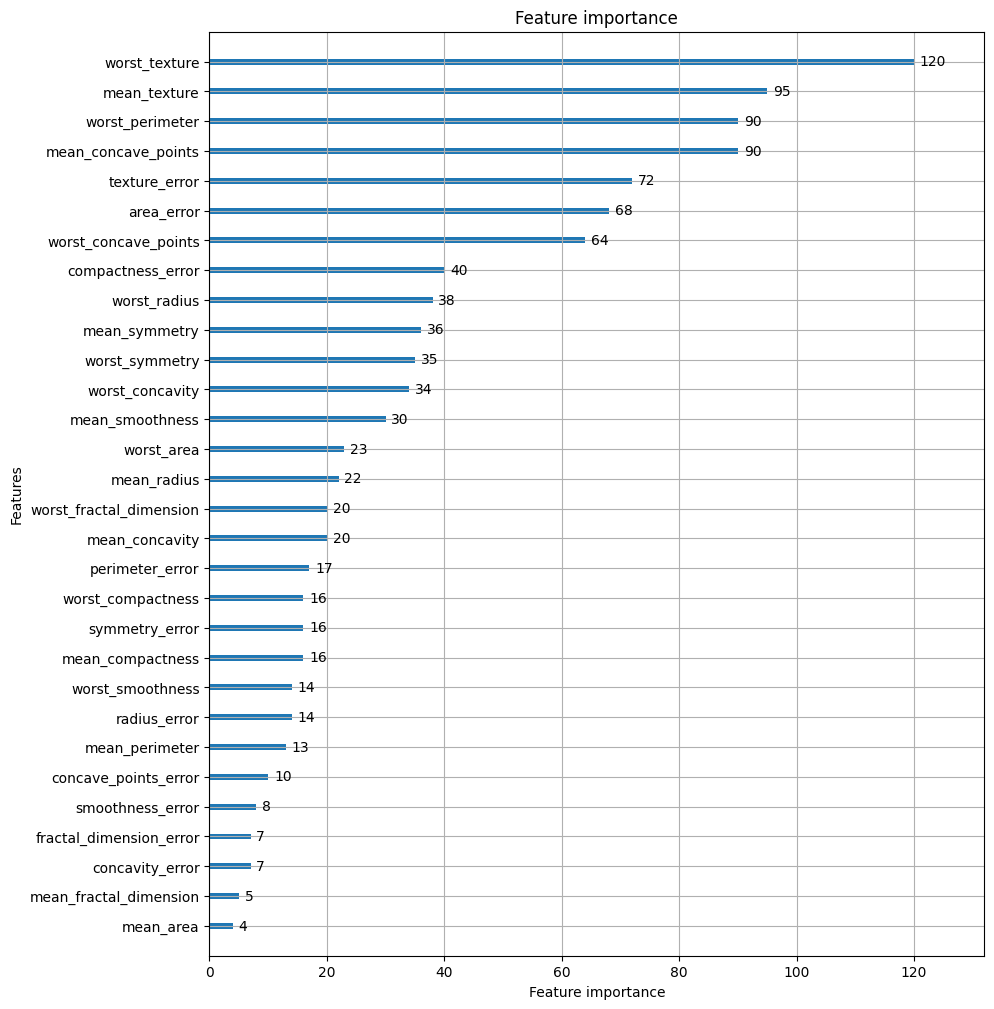

In [6]:
# LightGBM의 파이썬 패키지인 lightgbm에서 LGBMClassifier 임포트
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)

cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156
)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156
)

# 앞서 XGBoost와 동일하게 n_estimators는 400 설정.
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05)

# LightGBM도 XGBoost와 동일하게 조기 중단 수행 가능.
evals = [(X_tr, y_tr), (X_val, y_val)]

lgbm_wrapper.fit(
    X_tr,
    y_tr,
    early_stopping_rounds=50,
    eval_metric="logloss",
    eval_set=evals,
    verbose=True
)

preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

# plot_importance()를 이용하여 feature 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt

%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)

4.8 HyperOpt를 이용한 하이퍼 파라미터 튜닝

In [7]:
pip install hyperopt

In [8]:
from hyperopt import hp

# -10 ~ 10까지 1간격으로 입력 변수 x와 -15 ~ 15까지 1간격으로 입력 변수 y 설정.
search_space = {'x': hp.quniform('x', -10, 10, 1), 'y': hp.quniform('y', -15, 15, 1)}

from hyperopt import fmin, tpe, Trials

# 목적 함수를 생성. 변수값과 변수명을 가지는 딕셔너리를 인자로 받고, 특정 값을 반환
def objective_func(search_space):
    x = search_space['x']
    y = search_space['y']
    retval = x**2 - 20*y

    return retval

# 결과 저장용 Trials 객체 생성.
trials_obj = Trials()

# 목적 함수를 최소화하는 입력 변수값을 5번의 시도 만에 찾아줌.
best = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=5, trials=trials_obj)
print('best:', best)

100%|██████████| 5/5 [00:00<00:00, 197.33trial/s, best loss: -115.0]
best: {'x': np.float64(-5.0), 'y': np.float64(7.0)}


4.10 스태킹 앙상블

In [9]:
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer_data = load_breast_cancer()

X_data = cancer_data.data
y_label = cancer_data.target

X_train , X_test , y_train , y_test = train_test_split(X_data , y_label , test_size=0.2 , random_state=0)

# 개별 ML 모델 생성
knn_clf  = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(n_estimators=100)

# 스태킹으로 만들어진 데이터 세트를 학습, 예측할 최종 모델
lr_final = LogisticRegression(C=10)

# 개별 모델들을 학습.
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)
ada_clf.fit(X_train, y_train)

# 학습된 개별 모델들이 각자 반환하는 예측 데이터 세트를 생성하고 개별 모델의 정확도 측정.
knn_pred = knn_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
dt_pred = dt_clf.predict(X_test)
ada_pred = ada_clf.predict(X_test)

print('KNN 정확도: {0:.4f}'.format(accuracy_score(y_test, knn_pred)))
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy_score(y_test, rf_pred)))
print('결정 트리 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))
print('에이다부스트 정확도: {0:.4f}'.format(accuracy_score(y_test, ada_pred)))

# 개별 예측 결과를 칼럼 레벨로 옆으로 붙여서 피처 값으로 만듦
stacked_pred = np.array([knn_pred, rf_pred, dt_pred, ada_pred])
# transpose를 이용해 행과 열의 위치를 바꿈. 컬럼 레벨로 각 모델의 예측 결과를 피처로 만듦.
stacked_pred = np.transpose(stacked_pred)

# 최종 메타 모델은 개별 모델의 예측 결과 피처 데이터 세트와 결정 레이블 데이터를 학습.
lr_final.fit(stacked_pred, y_test)
final_pred = lr_final.predict(stacked_pred)

print('최종 메타 모델의 예측 정확도: {0:.4f}'.format(accuracy_score(y_test, final_pred)))

KNN 정확도: 0.9211
랜덤 포레스트 정확도: 0.9649
결정 트리 정확도: 0.8947
에이다부스트 정확도: 0.9737
최종 메타 모델의 예측 정확도: 0.9825


4.11 SMOTE (신용카드 사기 검출)

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print('SMOTE 적용 전 학습용 피처/레이블 데이터 세트: ', X_train.shape, y_train.shape)
print('SMOTE 적용 후 학습용 피처/레이블 데이터 세트: ', X_train_over.shape, y_train_over.shape)
print('SMOTE 적용 후 레이블 값 분포: \n', pd.Series(y_train_over).value_counts())

# SMOTE 적용된 학습 데이터 세트로 다시 학습 수행
lr_clf = LogisticRegression()
# ftr_train과 tgt_train 인자값이 아닌 smote로 증식된 데이터를 입력함.
lr_clf.fit(X_train_over, y_train_over)
lr_preds = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]

# 실제 예측 성능 평가
get_clf_eval(y_test, lr_preds, lr_pred_proba)

SMOTE 적용 전 학습용 피처/레이블 데이터 세트:  (455, 30) (455,)
SMOTE 적용 후 학습용 피처/레이블 데이터 세트:  (580, 30) (580,)
SMOTE 적용 후 레이블 값 분포: 
 1    290
0    290
Name: count, dtype: int64
오차 행렬
[[46  1]
 [ 5 62]]
정확도: 0.9474, 정밀도: 0.9841, 재현율: 0.9254,    F1: 0.9538, AUC:0.9902
